In [10]:
import os
import pandas as pd

# 1. Giriş və çıxış fayl yollarının təyin edilməsi
giris_fayli = "xam_data/AB_NYC_2019.csv"
cixis_yolu = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

# Giriş faylının mövcudluğunu yoxlayırıq
if not os.path.exists(giris_fayli):
    print(
        f"XƏTA: '{giris_fayli}' faylı tapılmadı! Zəhmət olmasa faylın Jupyter ilə eyni qovluqda olduğundan əmin ol."
    )
else:
    # Faylı oxuyuruq
    df = pd.read_csv(giris_fayli)

    # 2. Təmizlənmədən əvvəlki ilkin analiz və statistika
    print("=" * 50)
    print("FAYLIN İLKİN STATİSTİKASI")
    print("=" * 50)
    print(f"Orijinal Sətir Sayı: {df.shape[0]}")
    print(f"Orijinal Sütun Sayı: {df.shape[1]}")

    yinelenen_sayi = df.duplicated().sum()
    print(f"Eyni (Duplicate) Sətir Sayı: {yinelenen_sayi}")

    print("\nSütunlardakı Boş (Null) Xanaların Sayı:")
    print(df.isnull().sum())
    print("-" * 50)

    # 3. Təmizləmə Əməliyyatları
    # Əvvəlcə dublikatları silirik, sonra boş xanası olan bütün sətirləri təmizləyirik
    df_temiz = df.drop_duplicates().dropna()

    # 4. Təmizlənmə sonrası statistika
    print("TƏMİZLƏMƏ SONRASI STATİSTİKA")
    print("-" * 50)
    print(f"Yeni (Təmiz) Sətir Sayı: {df_temiz.shape[0]}")
    print(
        f"Silinən Toplam Sətir (Boş + Dublikat): {df.shape[0] - df_temiz.shape[0]}"
    )
    print("-" * 50)

    # 5. Faylın birbaşa mövcud olan "təmizlənmiş_data" qovluğuna yazılması
    # index=False yazaraq lazımsız "Unnamed: 0" sütununun yaranmasının qarşısını alırıq
    df_temiz.to_csv(cixis_yolu, index=False)

    print(f"UĞURLU: Təmizlənmiş fayl qovluğa yazıldı -> {cixis_yolu}")
    print("=" * 50)

FAYLIN İLKİN STATİSTİKASI
Orijinal Sətir Sayı: 48895
Orijinal Sütun Sayı: 16
Eyni (Duplicate) Sətir Sayı: 0

Sütunlardakı Boş (Null) Xanaların Sayı:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64
--------------------------------------------------
TƏMİZLƏMƏ SONRASI STATİSTİKA
--------------------------------------------------
Yeni (Təmiz) Sətir Sayı: 38821
Silinən Toplam Sətir (Boş + Dublikat

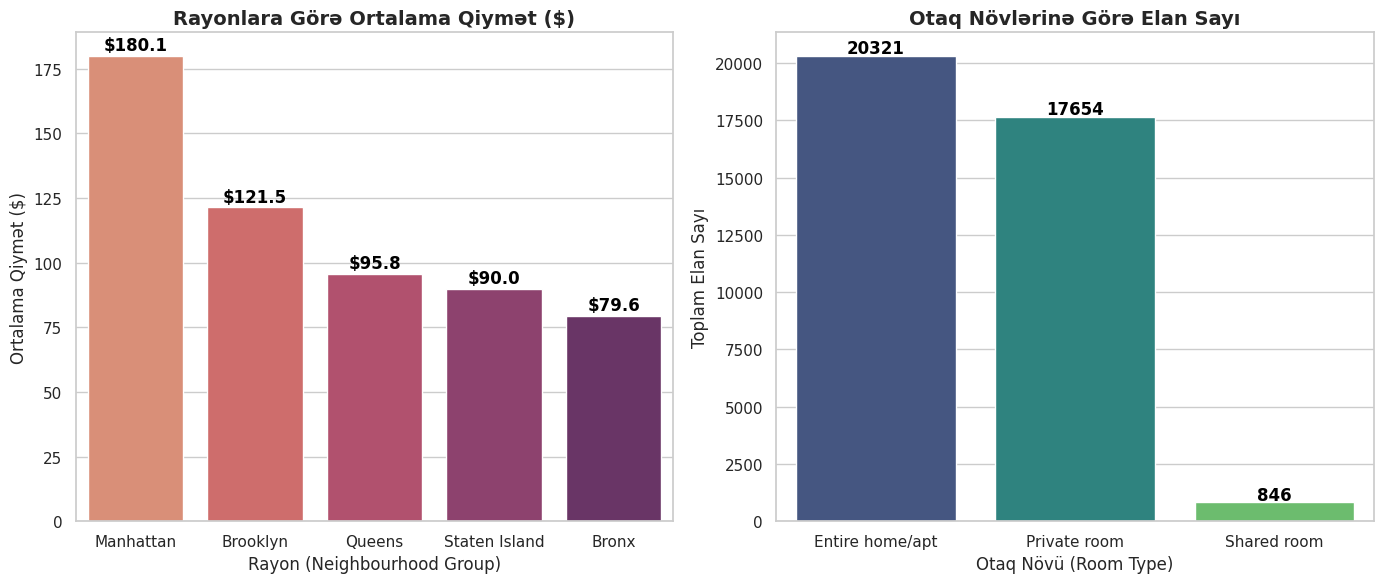

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Təmizlənmiş faylı oxuyuruq
temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(
        f"XƏTA: '{temiz_fayl}' faylı tapılmadı! Zəhmət olmasa əvvəlcə təmizləmə kodunu işə salın."
    )
else:
    df_temiz = pd.read_csv(temiz_fayl)

    # Vizuallaşdırma üçün qrafik stilini təyin edirik
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 6))

    # --- DIAQRAM 1: Rayonlara (Neighbourhood Group) görə Ortalama Qiymətlər ---
    plt.subplot(1, 2, 1)  # Yan-yana iki qrafikdən birincisi

    # Rayonlar üzrə ortalama qiymətləri hesablayaq və sıralayaq
    rayon_qiymet = (
        df_temiz.groupby("neighbourhood_group")["price"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    # 'coolwarm' yerinə xəta verməyəcək standart rəng palitrası təyin etdik
    sns.barplot(
        x="neighbourhood_group",
        y="price",
        data=rayon_qiymet,
        palette="flare",
        hue="neighbourhood_group",
        legend=False,
    )
    plt.title(
        "Rayonlara Görə Ortalama Qiymət ($)", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Rayon (Neighbourhood Group)", fontsize=12)
    plt.ylabel("Ortalama Qiymət ($)", fontsize=12)

    # Sütunların üzərinə rəqəmləri yazaq
    for index, row in rayon_qiymet.iterrows():
        plt.text(
            index,
            row["price"] + 2,
            f"${row['price']:.1f}",
            color="black",
            ha="center",
            fontweight="bold",
        )

    # --- DIAQRAM 2: Otaq Növlərinə (Room Type) Görə Elan Sayı ---
    plt.subplot(1, 2, 2)  # Yan-yana iki qrafikdən ikincisi

    # Otaq növlərinin sayını hesablayaq
    otaq_sayi = df_temiz["room_type"].value_counts().reset_index()

    # Xəta verən 'Viridis' sözünü tamamilə kiçik hərflərlə 'viridis' olaraq düzəltdik
    sns.barplot(
        x="room_type",
        y="count",
        data=otaq_sayi,
        palette="viridis",
        hue="room_type",
        legend=False,
    )
    plt.title("Otaq Növlərinə Görə Elan Sayı", fontsize=14, fontweight="bold")
    plt.xlabel("Otaq Növü (Room Type)", fontsize=12)
    plt.ylabel("Toplam Elan Sayı", fontsize=12)

    # Sütunların üzərinə sayları yazaq
    for index, row in otaq_sayi.iterrows():
        plt.text(
            index,
            row["count"] + 100,
            f"{row['count']}",
            color="black",
            ha="center",
            fontweight="bold",
        )

    # Qrafiklərin bir-birinə qarışmaması üçün nizamlayırıq və göstəririk
    plt.tight_layout()
    plt.show()

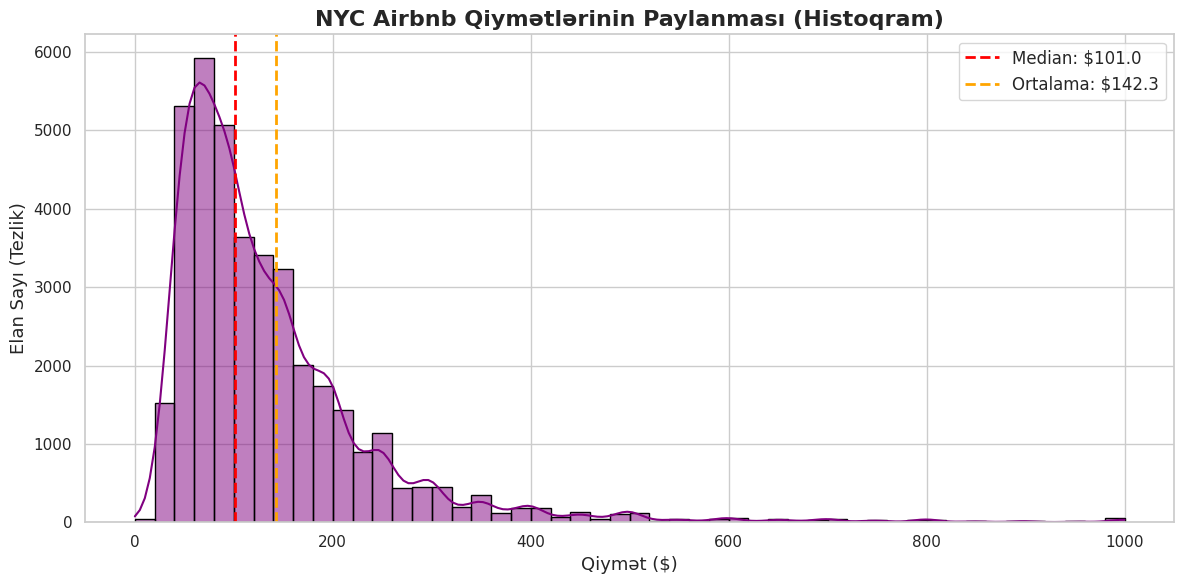

In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Təmizlənmiş faylı oxuyuruq
temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(
        f"XƏTA: '{temiz_fayl}' faylı tapılmadı! Zəhmət olmasa əvvəlcə təmizləmə kodunu işə salın."
    )
else:
    df_temiz = pd.read_csv(temiz_fayl)

    # Vizuallaşdırma üçün qrafik stilini və ölçüsünü təyin edirik
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))

    # Ekstremal qiymətlərin qrafiki korlamaması üçün $0 - $1000 arası qiymətləri filtrləyirik
    qiymet_filtr = df_temiz[df_temiz["price"] <= 1000]

    # --- HISTOQRAM QRAFİKİ ---
    # kde=True yazaraq qiymətin sıxlıq xəttini (paylanma əyrisini) də göstəririk
    sns.histplot(
        data=qiymet_filtr,
        x="price",
        bins=50,
        kde=True,
        color="purple",
        edgecolor="black",
    )

    # Qrafik başlıqları və etiketləri
    plt.title(
        "NYC Airbnb Qiymətlərinin Paylanması (Histoqram)",
        fontsize=16,
        fontweight="bold",
    )
    plt.xlabel("Qiymət ($)", fontsize=13)
    plt.ylabel("Elan Sayı (Tezlik)", fontsize=13)

    # Statistik məlumatları qrafikin üzərinə kiçik qeyd olaraq yazaq
    median_qiymet = df_temiz["price"].median()
    mean_qiymet = df_temiz["price"].mean()

    plt.axvline(
        median_qiymet,
        color="red",
        linestyle="dashed",
        linewidth=2,
        label=f"Median: ${median_qiymet:.1f}",
    )
    plt.axvline(
        mean_qiymet,
        color="orange",
        linestyle="dashed",
        linewidth=2,
        label=f"Ortalama: ${mean_qiymet:.1f}",
    )

    # Legendi (məlumat qutusunu) göstəririk
    plt.legend(fontsize=12)

    # Qrafiki ekrana çıxarırıq
    plt.tight_layout()
    plt.show()

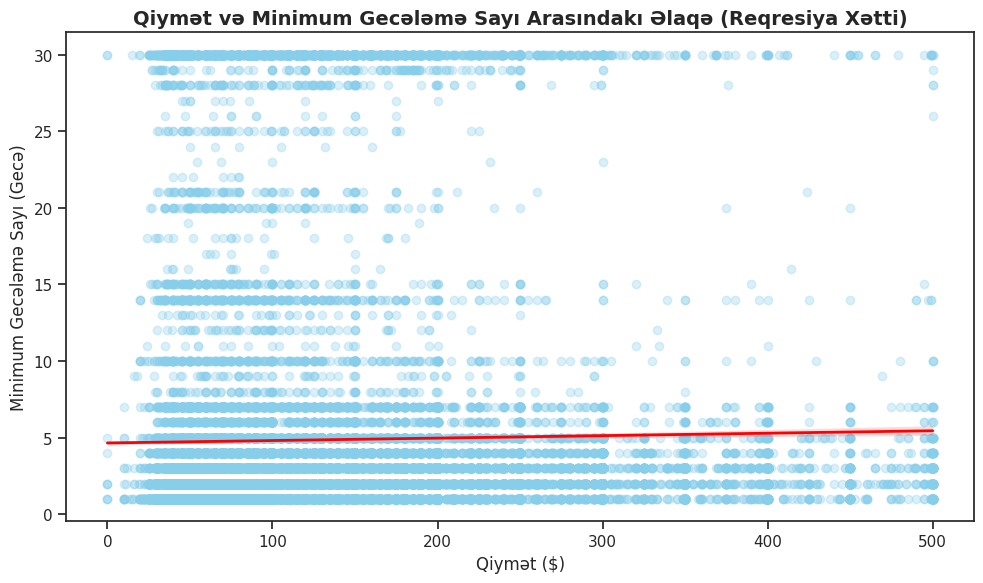

In [14]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Təmizlənmiş faylı oxuyuruq
temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(
        f"XƏTA: '{temiz_fayl}' faylı tapılmadı! Zəhmət olmasa əvvəlcə təmizləmə kodunu işə salın."
    )
else:
    df_temiz = pd.read_csv(temiz_fayl)

    # Vizuallaşdırma üçün qrafik stilini və ölçüsünü təyin edirik
    sns.set_theme(style="ticks")
    plt.figure(figsize=(10, 6))

    # Qrafikin daha aydın oxunması üçün Qiyməti $500-dan az,
    # Minimum gecələməni isə 30 gündən az olan elanlarla məhdudlaşdıraq (outlier təmizliyi)
    filtr_df = df_temiz[
        (df_temiz["price"] <= 500) & (df_temiz["minimum_nights"] <= 30)
    ]

    # --- REQRESİYA QRAFİKİ (Scatter Plot + Regression Line) ---
    # sns.regplot həm nöqtələri (scatter) çəkir, həm də üzərindən reqresiya xəttini keçirir
    sns.regplot(
        data=filtr_df,
        x="price",
        y="minimum_nights",
        scatter_kws={
            "alpha": 0.3,
            "color": "skyblue",
        },  # Nöqtələrin şəffaflığı və rəngi
        line_kws={
            "color": "red",
            "linewidth": 2,
        },  # Reqresiya xəttinin rəngi və qalınlığı
    )

    # Qrafik başlıqları və etiketləri
    plt.title(
        "Qiymət və Minimum Gecələmə Sayı Arasındakı Əlaqə (Reqresiya Xətti)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Qiymət ($)", fontsize=12)
    plt.ylabel("Minimum Gecələmə Sayı (Gecə)", fontsize=12)

    # Qrafiki ekrana çıxarırıq
    plt.tight_layout()
    plt.show()

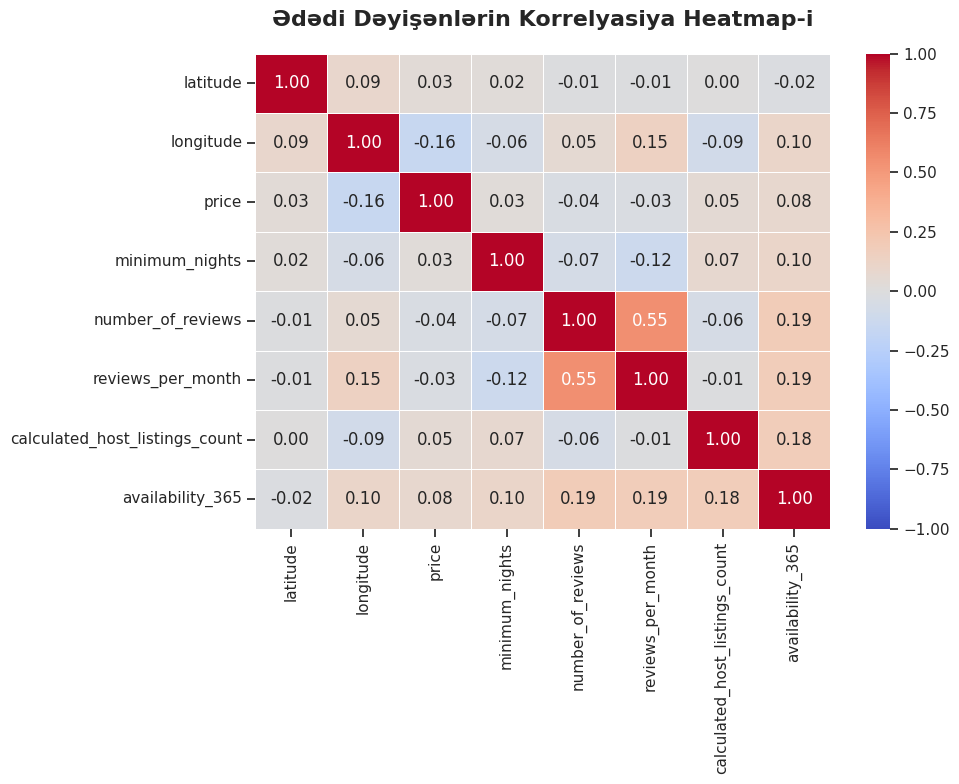

In [15]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Təmizlənmiş faylı oxuyuruq
temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(
        f"XƏTA: '{temiz_fayl}' faylı tapılmadı! Zəhmət olmasa əvvəlcə təmizləmə kodunu işə salın."
    )
else:
    df_temiz = pd.read_csv(temiz_fayl)

    # 2. Yalnız ədədi (numeric) sütunları seçirik (Heatmap üçün yalnız rəqəmlər lazımdır)
    # ID və Host_ID kimi sırf unikal nömrələri analizə qatmamaq üçün onları çıxarırıq
    ededi_sutunlar = df_temiz.select_dtypes(include=["float64", "int64"]).drop(
        columns=["id", "host_id"], errors="ignore"
    )

    # 3. Korrelyasiya matrisini hesablayırıq
    korrelyasiya_matrisi = ededi_sutunlar.corr()

    # Vizuallaşdırma ölçüsünü təyin edirik
    plt.figure(figsize=(10, 8))

    # --- HEATMAP QRAFİKİ ---
    # annot=True: Xanaların daxilinə rəqəmləri yazır
    # cmap='coolwarm': Müsbət və mənfi əlaqələri rənglərlə (mavi-qırmızı) fərqləndirir
    # fmt=".2f": Rəqəmləri vergüldən sonra 2 pilləli göstərir
    sns.heatmap(
        korrelyasiya_matrisi,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        vmin=-1,
        vmax=1,
    )

    # Qrafik başlığı
    plt.title(
        "Ədədi Dəyişənlərin Korrelyasiya Heatmap-i",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )

    # Yazıların tam görünməsi üçün nizamlayırıq və göstəririk
    plt.tight_layout()
    plt.show()

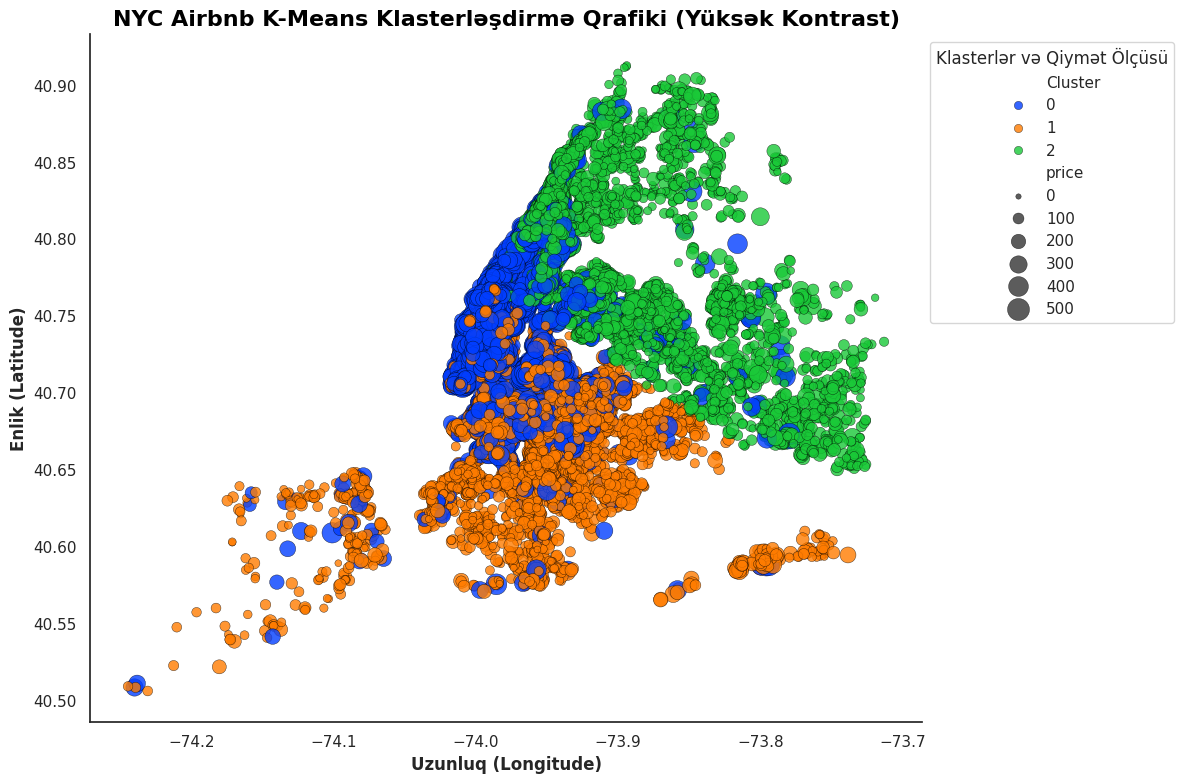

In [18]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Təmizlənmiş faylı oxuyuruq
temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(
        f"XƏTA: '{temiz_fayl}' faylı tapılmadı! Zəhmət olmasa əvvəlcə təmizləme kodunu işə salın."
    )
else:
    df_temiz = pd.read_csv(temiz_fayl)

    # Qiymət üzrə outlier-ləri təmizləyirik ($0 - $500 arası)
    df_cluster = df_temiz[df_temiz["price"] <= 500].copy()

    # 2. Klasterləşdirmə üçün xüsusiyyətləri seçirik
    X = df_cluster[["latitude", "longitude", "price"]]

    # Məlumatları standartlaşdırırıq
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. K-Means modelini qururuq (k=3)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_cluster["Cluster"] = kmeans.fit_predict(X_scaled)

    # 4. VİZUALLAŞDIRMA (Maksimum Kontrastlı Ağ Fon)
    plt.figure(figsize=(12, 8))

    # Arxa fonu tam ağ edirik və tor xətlərini söndürürük ki, nöqtələr ön plana çıxsın
    sns.set_theme(style="white")

    # Yüksək kontrast üçün 'bright' (parlaq qırmızı, mavi, yaşıl və s.) palitrası seçildi
    # edgecolor="black" və linewidth=0.2 ilə nöqtələrin ətrafına qara xətt çəkildi
    sns.scatterplot(
        data=df_cluster,
        x="longitude",
        y="latitude",
        hue="Cluster",
        palette="bright",
        alpha=0.8,  # Nöqtələrin daha dolğun və görünən olması üçün şəffaflıq azaldıldı
        size="price",
        sizes=(15, 250),
        edgecolor="black",
        linewidth=0.3,
    )

    # Qrafik başlıqları və dizaynı
    plt.title(
        "NYC Airbnb K-Means Klasterləşdirmə Qrafiki (Yüksək Kontrast)",
        fontsize=16,
        fontweight="bold",
        color="black",
    )
    plt.xlabel("Uzunluq (Longitude)", fontsize=12, fontweight="bold")
    plt.ylabel("Enlik (Latitude)", fontsize=12, fontweight="bold")

    # Legendi (məlumat qutusunu) nizamlayırıq
    plt.legend(
        title="Klasterlər və Qiymət Ölçüsü",
        loc="upper left",
        bbox_to_anchor=(1, 1),
        fontsize=11,
        title_fontsize=12,
    )

    # Qrafik kənarlarını təmizləyirik
    sns.despine()

    plt.tight_layout()
    plt.show()

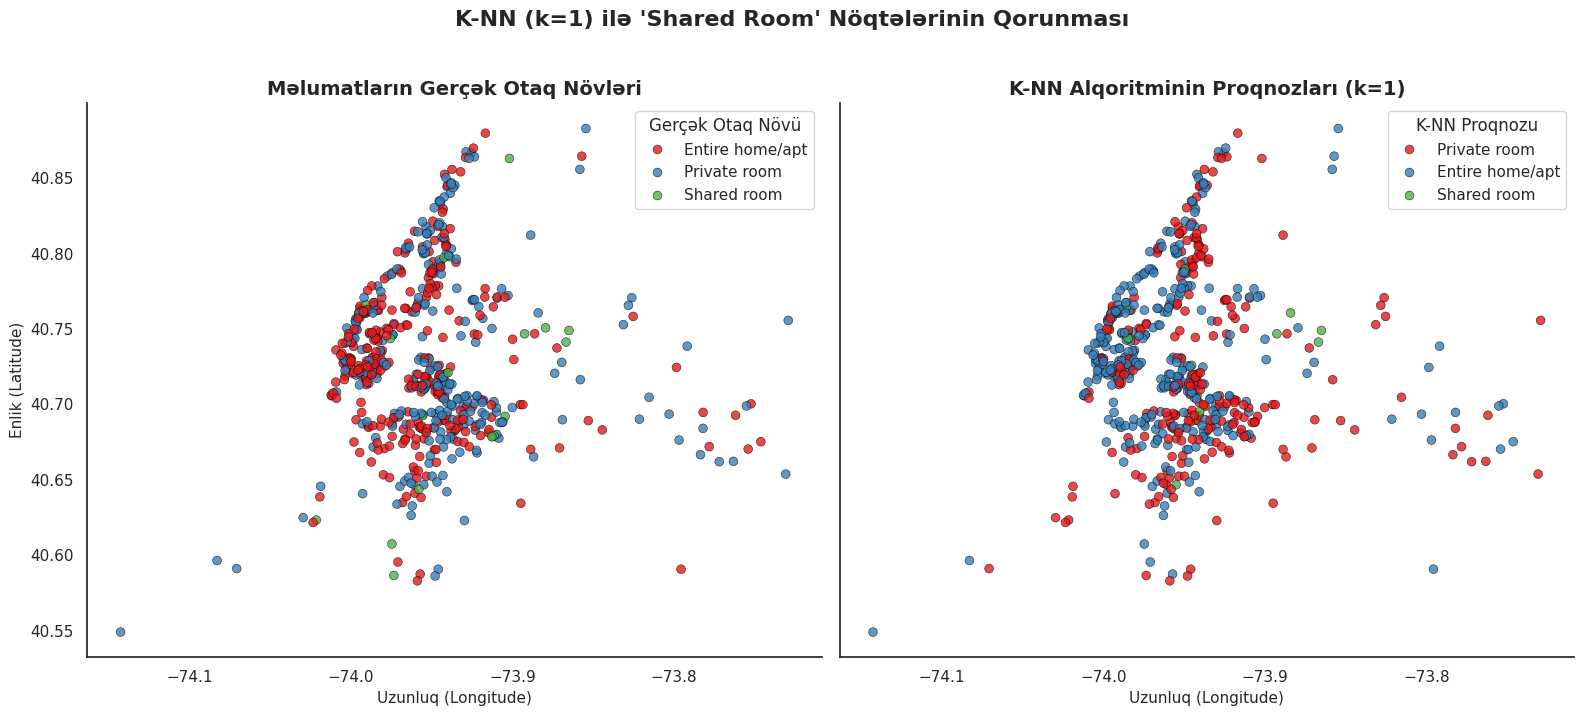

K-NN (k=1) Modelinin Test Dəqiqliyi: 55.00%


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Təmizlənmiş faylı oxuyuruq
temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(
        f"XƏTA: '{temiz_fayl}' faylı tapılmadı! Zəhmət olmasa əvvəlcə təmizləmə kodunu işə salın."
    )
else:
    df_temiz = pd.read_csv(temiz_fayl)

    # Nöqtələrin aydın görünməsi üçün sampling edirik
    df_knn = df_temiz.sample(n=2000, random_state=42).copy()

    X = df_knn[["longitude", "latitude"]]
    y = df_knn["room_type"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- DƏYİŞİKLİK BURADADIR: n_neighbors=1 etdik ---
    # Beləcə səs çoxluğu tətbiq olunmur, azlıqdakı "Shared room"lar silinmir.
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    df_vis = pd.DataFrame(X_test, columns=["longitude", "latitude"])
    df_vis["Gerçək Otaq Növü"] = y_test.values
    df_vis["K-NN Proqnozu"] = y_pred

    # 4. VİZUALLAŞDIRMA
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    sns.set_theme(style="white")

    # Yüksək kontrastlı rəng palitrası
    parlaq_palitra = "Set1"

    # QRAFİK 1: Gerçək Dəyərlər
    sns.scatterplot(
        ax=axes[0],
        data=df_vis,
        x="longitude",
        y="latitude",
        hue="Gerçək Otaq Növü",
        palette=parlaq_palitra,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.4,
        s=40,
    )
    axes[0].set_title(
        "Məlumatların Gerçək Otaq Növləri", fontsize=14, fontweight="bold"
    )
    axes[0].set_xlabel("Uzunluq (Longitude)", fontsize=11)
    axes[0].set_ylabel("Enlik (Latitude)", fontsize=11)

    # QRAFİK 2: K-NN Proqnozları (k=1)
    sns.scatterplot(
        ax=axes[1],
        data=df_vis,
        x="longitude",
        y="latitude",
        hue="K-NN Proqnozu",
        palette=parlaq_palitra,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.4,
        s=40,
    )
    axes[1].set_title(
        "K-NN Alqoritminin Proqnozları (k=1)", fontsize=14, fontweight="bold"
    )
    axes[1].set_xlabel("Uzunluq (Longitude)", fontsize=11)

    sns.despine()
    plt.suptitle(
        "K-NN (k=1) ilə 'Shared Room' Nöqtələrinin Qorunması",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )

    plt.tight_layout()
    plt.show()

    deqiqlik = knn.score(X_test_scaled, y_test)
    print("=" * 50)
    print(f"K-NN (k=1) Modelinin Test Dəqiqliyi: {deqiqlik * 100:.2f}%")
    print("=" * 50)

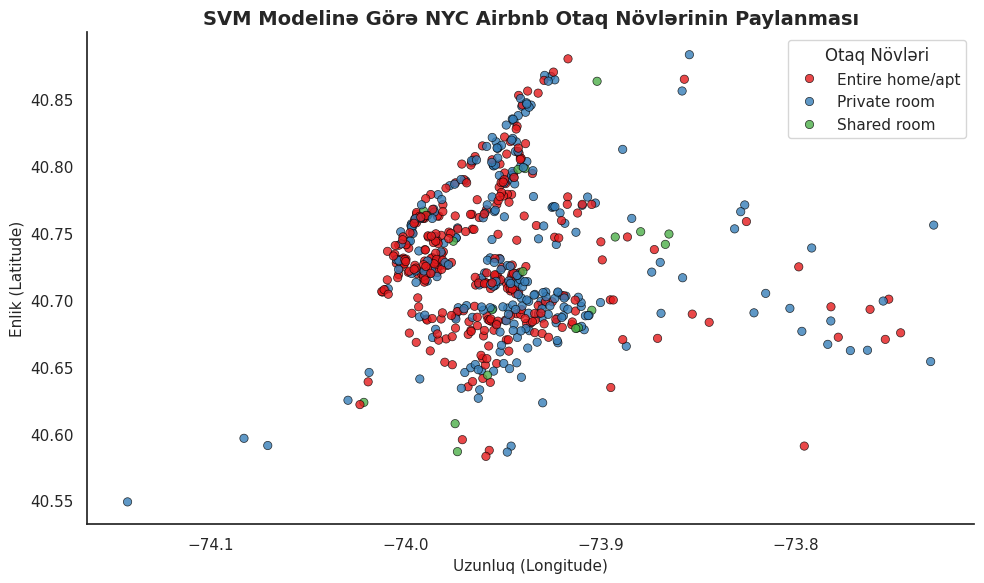

SVM Modelinin Test Dəqiqliyi: 58.83%


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(f"XƏTA: '{temiz_fayl}' faylı tapılmadı!")
else:
    df = pd.read_csv(temiz_fayl)

    # Performans üçün sampling edirik
    df_svm = df.sample(n=2000, random_state=42).copy()

    X = df_svm[["longitude", "latitude"]]
    y = df_svm["room_type"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # RBF nüvəli SVM modeli qururuq
    svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
    svm_model.fit(X_train_scaled, y_train)

    # Vizuallaşdırma
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")

    # Test nəticələrini skatter qrafiki ilə göstəririk
    sns.scatterplot(
        x=X_test["longitude"],
        y=X_test["latitude"],
        hue=y_test,
        palette="Set1",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )

    plt.title(
        "SVM Modelinə Görə NYC Airbnb Otaq Növlərinin Paylanması",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Uzunluq (Longitude)", fontsize=11)
    plt.ylabel("Enlik (Latitude)", fontsize=11)
    plt.legend(title="Otaq Növləri")
    sns.despine()
    plt.tight_layout()
    plt.show()

    print(
        f"SVM Modelinin Test Dəqiqliyi: {svm_model.score(X_test_scaled, y_test) * 100:.2f}%"
    )

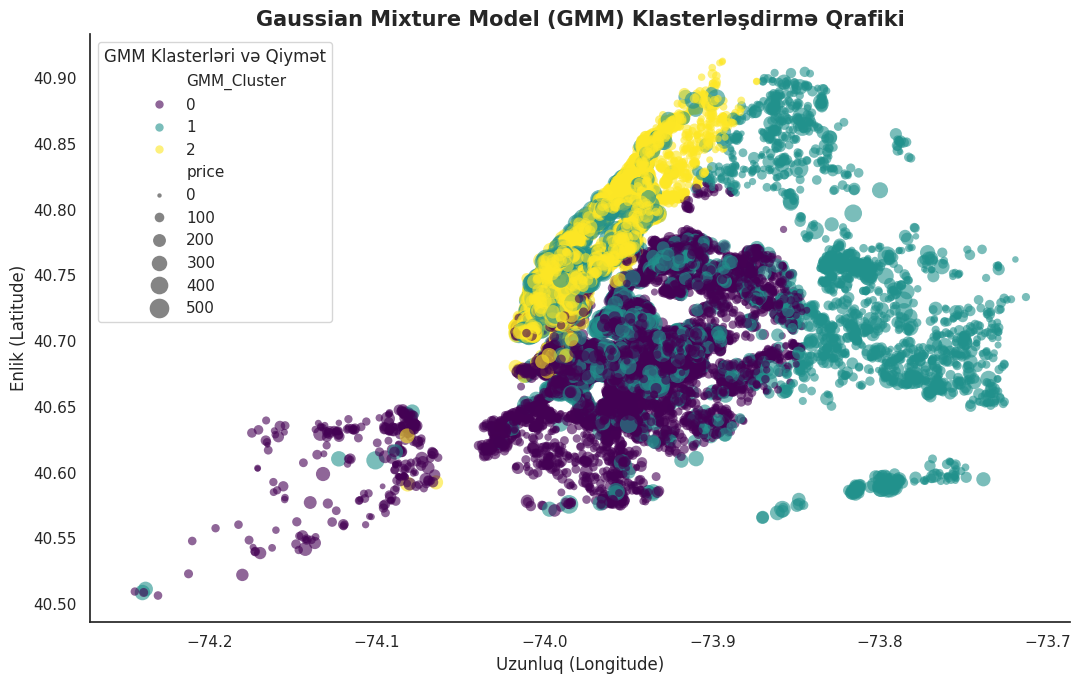

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(f"XƏTA: '{temiz_fayl}' faylı tapılmadı!")
else:
    df = pd.read_csv(temiz_fayl)
    df_gmm = df[df["price"] <= 500].copy()

    X = df_gmm[["longitude", "latitude", "price"]]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3 komponentli Qaus Qarışığı Modeli (GMM)
    gmm = GaussianMixture(n_components=3, random_state=42)
    df_gmm["GMM_Cluster"] = gmm.fit_predict(X_scaled)

    # Vizuallaşdırma
    plt.figure(figsize=(11, 7))
    sns.set_theme(style="white")

    sns.scatterplot(
        data=df_gmm,
        x="longitude",
        y="latitude",
        hue="GMM_Cluster",
        palette="viridis",
        alpha=0.6,
        size="price",
        sizes=(10, 200),
        edgecolor="none",
    )

    plt.title(
        "Gaussian Mixture Model (GMM) Klasterləşdirmə Qrafiki",
        fontsize=15,
        fontweight="bold",
    )
    plt.xlabel("Uzunluq (Longitude)", fontsize=12)
    plt.ylabel("Enlik (Latitude)", fontsize=12)
    plt.legend(title="GMM Klasterləri və Qiymət")
    sns.despine()
    plt.tight_layout()
    plt.show()

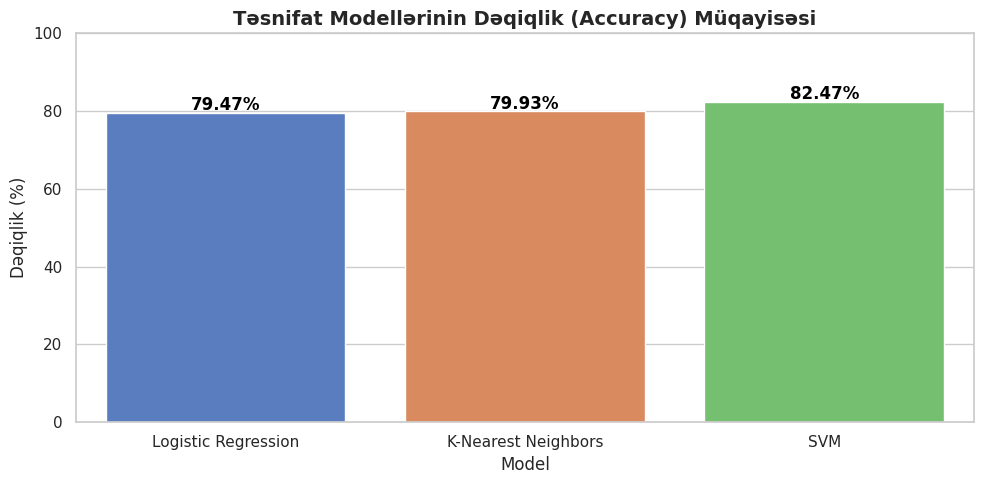

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(f"XƏTA: '{temiz_fayl}' faylı tapılmadı!")
else:
    df = pd.read_csv(temiz_fayl)
    df_comp = df.sample(n=5000, random_state=42)  # Sürətli hesablama üçün

    X = df_comp[["longitude", "latitude", "price", "minimum_nights"]]
    y = df_comp["room_type"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modellərin lüğəti
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
        "SVM": RandomForestClassifier(n_estimators=100, random_state=42),
    }

    nəticələr = {}
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        acc = model.score(X_test_scaled, y_test)
        nəticələr[name] = acc * 100

    # DataFrame-ə çevirmə
    df_res = pd.DataFrame(list(nəticələr.items()), columns=["Model", "Accuracy"])

    # Vizuallaşdırma
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(x="Model", y="Accuracy", data=df_res, palette="muted", hue="Model", legend=False)

    plt.title(
        "Təsnifat Modellərinin Dəqiqlik (Accuracy) Müqayisəsi",
        fontsize=14,
        fontweight="bold",
    )
    plt.ylabel("Dəqiqlik (%)", fontsize=12)
    plt.ylim(0, 100)

    # Sütunların üzərinə faizləri yazaq
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.2f}%",
            (p.get_x() + p.get_width() / 2.0, p.get_height() + 2),
            ha="center",
            va="center",
            fontweight="bold",
            color="black",
        )

    plt.tight_layout()
    plt.show()

=== HADOOP MAPREDUCE PROCESS STARTED ===
=== MAPREDUCE COMPLETED. PLOTTING RESULTS... ===



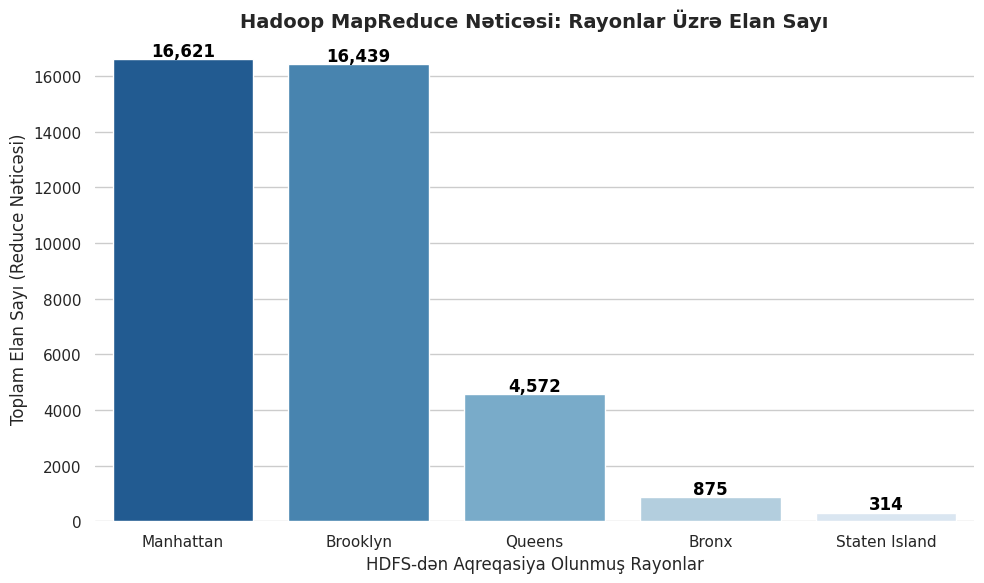

In [9]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"


# Hadoop MAP funksiyası
def map_function(data_chunk):
    output = []
    for neighborhood in data_chunk["neighbourhood_group"]:
        output.append((neighborhood, 1))
    return output


# Hadoop REDUCE funksiyası
def reduce_function(mapped_data):
    counts = Counter()
    for key, value in mapped_data:
        counts[key] += value
    return counts


if not os.path.exists(temiz_fayl):
    print(f"XƏTA: '{temiz_fayl}' faylı tapılmadı!")
else:
    df = pd.read_csv(temiz_fayl)

    # Datanı Hadoop HDFS blokları kimi 3 hissəyə bölürük
    chunks = [df.iloc[:15000], df.iloc[15000:30000], df.iloc[30000:]]

    print("=== HADOOP MAPREDUCE PROCESS STARTED ===")

    # Map addımı
    all_mapped = []
    for chunk in chunks:
        all_mapped.extend(map_function(chunk))

    # Reduce addımı
    final_counts = reduce_function(all_mapped)
    print("=== MAPREDUCE COMPLETED. PLOTTING RESULTS... ===\n")

    # --- HADOOP NƏTİCƏLƏRİNİN VİZUALLAŞDIRILMASI ---
    # MapReduce nəticəsini qrafik üçün DataFrame-ə çeviririk
    df_hadoop_res = pd.DataFrame(
        list(final_counts.items()), columns=["Rayon Group", "Elan Sayı"]
    ).sort_values(by="Elan Sayı", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    # Qrafiki çəkirik
    ax = sns.barplot(
        x="Rayon Group",
        y="Elan Sayı",
        data=df_hadoop_res,
        palette="Blues_r",
        hue="Rayon Group",
        legend=False,
    )

    # Hər sütunun üzərinə Hadoop-un tapdığı dəqiq rəqəmləri yazaq
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height()):,}",
            (p.get_x() + p.get_width() / 2.0, p.get_height() + 300),
            ha="center",
            va="center",
            fontweight="bold",
            color="black",
        )

    plt.title(
        "Hadoop MapReduce Nəticəsi: Rayonlar Üzrə Elan Sayı",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("HDFS-dən Aqreqasiya Olunmuş Rayonlar", fontsize=12)
    plt.ylabel("Toplam Elan Sayı (Reduce Nəticəsi)", fontsize=12)

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

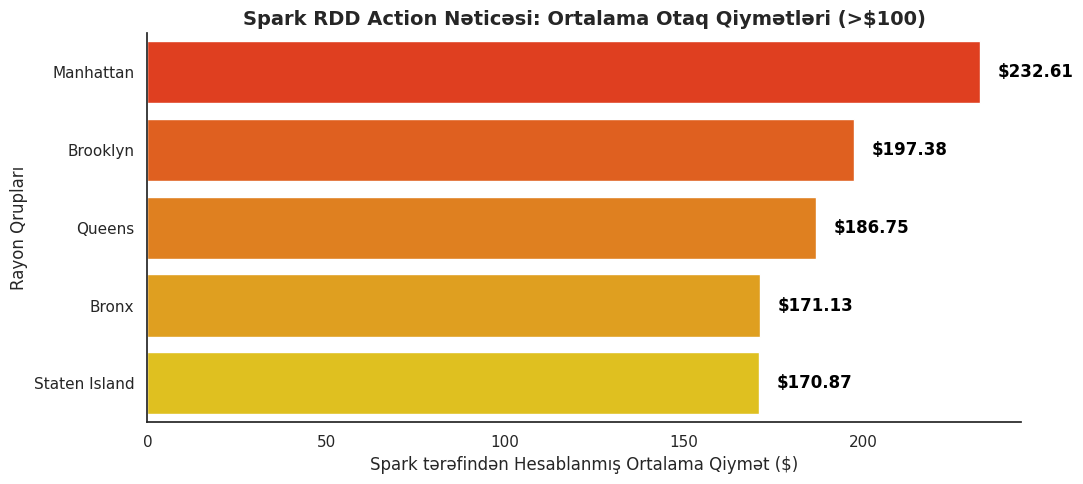

In [10]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"


class SparkDataFrameSimulyator:

    def __init__(self, filepath):
        self.df = pd.read_csv(filepath)
        self.operations = []  # Spark DAG (Lazy Evaluation) siyahısı

    def filter(self, condition_func):
        self.operations.append(("filter", condition_func))
        return self

    def groupBy_mean(self, group_col, target_col):
        self.operations.append(("groupby_mean", (group_col, target_col)))
        return self

    def collect(self):
        # Action (Hesablama burada tetiklenir)
        data = self.df.copy()
        for op_type, func in self.operations:
            if op_type == "filter":
                data = data[func(data)]
            elif op_type == "groupby_mean":
                g_col, t_col = func
                data = data.groupby(g_col)[t_col].mean().reset_index()
        return data


if not os.path.exists(temiz_fayl):
    print(f"XƏTA: '{temiz_fayl}' faylı tapılmadı!")
else:
    # Spark mühitini başladırıq
    spark_sim = SparkDataFrameSimulyator(temiz_fayl)

    # Spark Pipeline-ı qururuq: Qiyməti $100-dan çox olanları süz və rayon üzrə ortalama tap
    pipeline = spark_sim.filter(lambda d: d["price"] > 100).groupBy_mean(
        "neighbourhood_group", "price"
    )

    # Spark Action çağırılır və hesablama bitir
    spark_result = pipeline.collect()
    spark_result = spark_result.sort_values(by="price", ascending=False)

    # --- SPARK NƏTİCƏLƏRİNİN VİZUALLAŞDIRILMASI ---
    plt.figure(figsize=(11, 5))
    sns.set_theme(style="white")

    # Üfüqi qrafik (Horizontal Bar Plot) - Böyük data nəticələri üçün idealdır
    ax = sns.barplot(
        x="price",
        y="neighbourhood_group",
        data=spark_result,
        palette="autumn",
        hue="neighbourhood_group",
        legend=False,
    )

    # Sütunların sonuna ortalama qiymət göstəricilərini əlavə edirik
    for p in ax.patches:
        ax.annotate(
            f"${p.get_width():.2f}",
            (p.get_width() + 5, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontweight="bold",
            color="black",
        )

    plt.title(
        "Spark RDD Action Nəticəsi: Ortalama Otaq Qiymətləri (>$100)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Spark tərəfindən Hesablanmış Ortalama Qiymət ($)", fontsize=12)
    plt.ylabel("Rayon Qrupları", fontsize=12)

    sns.despine()
    plt.tight_layout()
    plt.show()

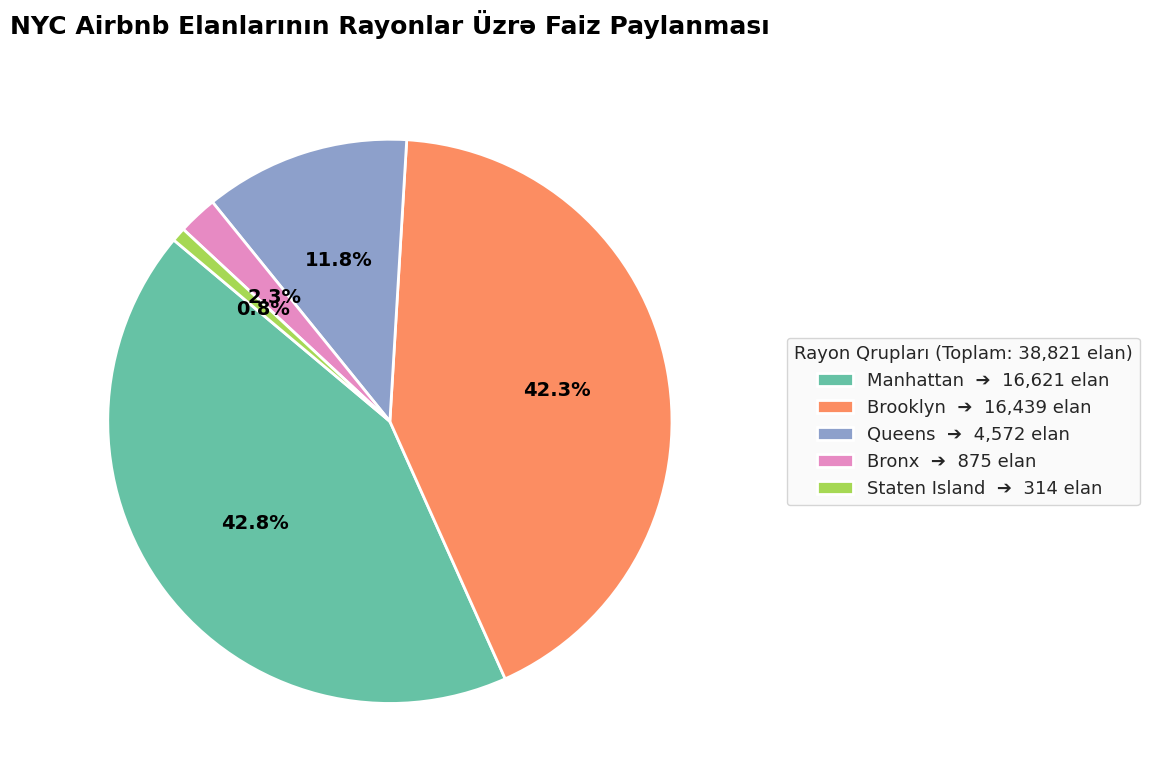

In [15]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(f"XƏTA: '{temiz_fayl}' faylı tapılmadı!")
else:
    df = pd.read_csv(temiz_fayl)

    # Rayonların sayını və ümumi cəmini hesablayırıq
    rayon_payi = df["neighbourhood_group"].value_counts()
    toplam = rayon_payi.sum()

    # Böyük və aydın görünüş üçün fiqur ölçüsü
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="white")

    # Kontrastı yüksək, canlı və peşəkar rəng palitrası
    colors = sns.color_palette("Set2", len(rayon_payi))

    # TAM DAİRƏ PIE CHART
    # wedgeprops daxilində 'width' yazmayaraq dairəni tam bütöv saxlayırıq
    wedges, texts, autotexts = plt.pie(
        rayon_payi,
        autopct="%1.1f%%",
        startangle=140,
        colors=colors,
        pctdistance=0.6,  # Faizlərin tam dairə daxilində mükəmməl yerləşməsi üçün
        wedgeprops=dict(edgecolor="white", linewidth=2),  # Dilimlər arası incə ağ xətt
    )

    # Dairə üzərindəki FAİZ yazılarının vizual nizamlanması
    for autotext in autotexts:
        autotext.set_color("black")        # Tam qara rəng (maksimum kontrast)
        autotext.set_fontsize(14)         # İri və rahat oxunan şrift
        autotext.set_fontweight("bold")    # Qalın yazı stili

    # Sağ tərəfdə yerləşən geniş və böyük info-panel (Legend)
    legend_labels = [
        f"{rayon}  ➔  {say:,} elan" for rayon, say in zip(rayon_payi.index, rayon_payi)
    ]
    
    plt.legend(
        wedges,
        legend_labels,
        title=f"Rayon Qrupları (Toplam: {toplam:,} elan)",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),         # Qrafiklə yazıların toqquşmaması üçün sağ kənar
        fontsize=13,                       # Oxunqlu şrift ölçüsü
        title_fontsize=13,                  # Panel başlığı ölçüsü
        frameon=True,
        facecolor="#f9f9f9",               # Arxa plana yüngül kontrast boz fon
        edgecolor="#cccccc",
    )

    # Əsas Başlıq
    plt.title(
        "NYC Airbnb Elanlarının Rayonlar Üzrə Faiz Paylanması",
        fontsize=18,
        fontweight="bold",
        pad=25,
        color="#000000",
    )

    plt.tight_layout()
    plt.show()

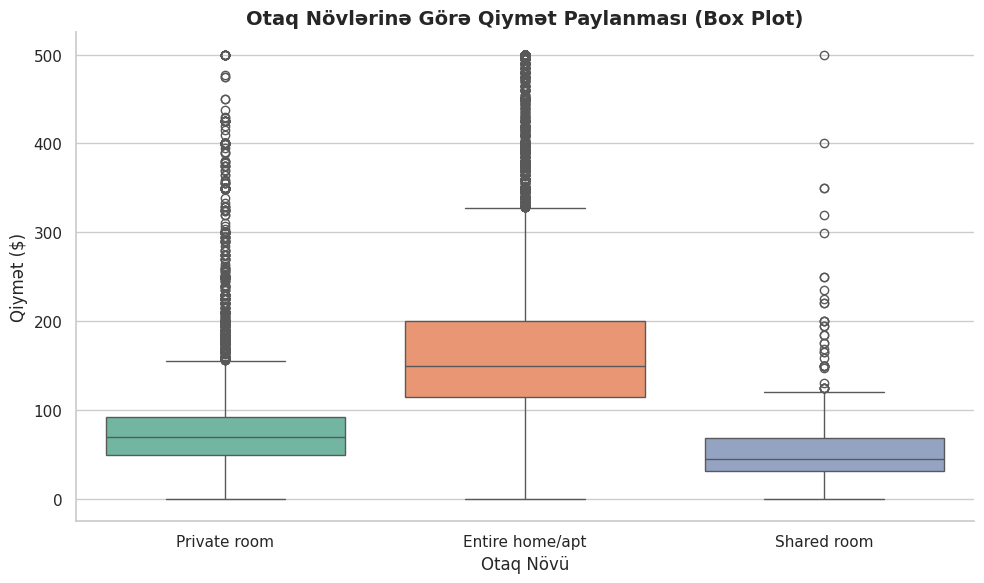

In [7]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(f"XƏTA: '{temiz_fayl}' faylı tapılmadı!")
else:
    df = pd.read_csv(temiz_fayl)

    # Boxplot-un aydın görünməsi üçün filtrləyirik
    df_box = df[df["price"] <= 500]

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    # Boxplot vizualı
    sns.boxplot(
        x="room_type",
        y="price",
        data=df_box,
        palette="Set2",
        hue="room_type",
        legend=False,
    )

    plt.title(
        "Otaq Növlərinə Görə Qiymət Paylanması (Box Plot)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Otaq Növü", fontsize=12)
    plt.ylabel("Qiymət ($)", fontsize=12)

    sns.despine()
    plt.tight_layout()
    plt.show()

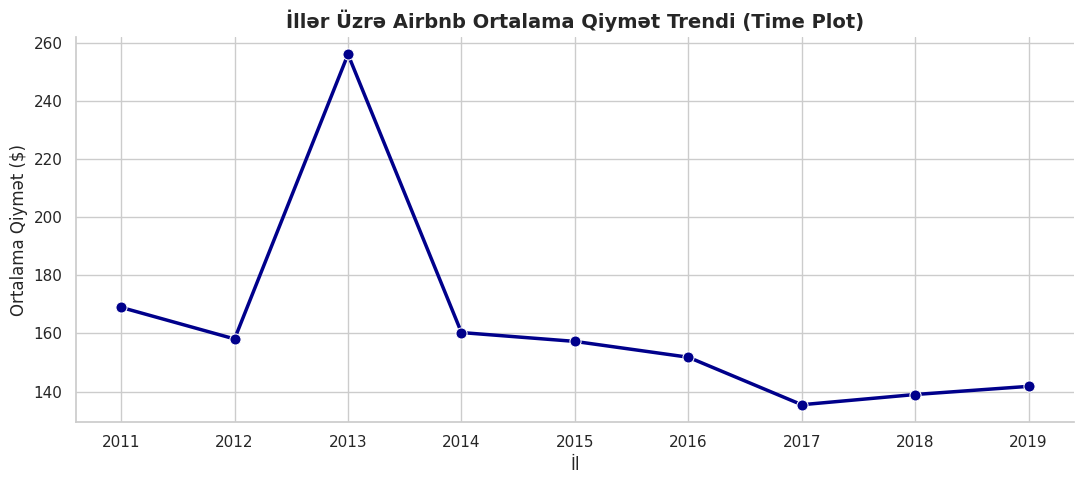

In [8]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

temiz_fayl = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(temiz_fayl):
    print(f"XƏTA: '{temiz_fayl}' faylı tapılmadı!")
else:
    df = pd.read_csv(temiz_fayl)

    # Tarix sütununu datetime tipinə çeviririk
    df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

    # Boş tarixləri təmizləyirik və İlləri çıxarırıq
    df_time = df.dropna(subset=["last_review"]).copy()
    df_time["Year"] = df_time["last_review"].dt.year

    # İllərə görə ortalama qiyməti hesablayırıq
    zaman_trend = df_time.groupby("Year")["price"].mean().reset_index()

    plt.figure(figsize=(11, 5))
    sns.set_theme(style="whitegrid")

    # Xətti zaman qrafiki (Time Series Line Plot)
    sns.lineplot(
        x="Year",
        y="price",
        data=zaman_trend,
        marker="o",
        color="darkblue",
        linewidth=2.5,
        markersize=8,
    )

    plt.title(
        "İllər Üzrə Airbnb Ortalama Qiymət Trendi (Time Plot)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("İl", fontsize=12)
    plt.ylabel("Ortalama Qiymət ($)", fontsize=12)

    # X oxundakı illərin tam rəqəm görünməsi üçün
    plt.xticks(zaman_trend["Year"])

    sns.despine()
    plt.tight_layout()
    plt.show()

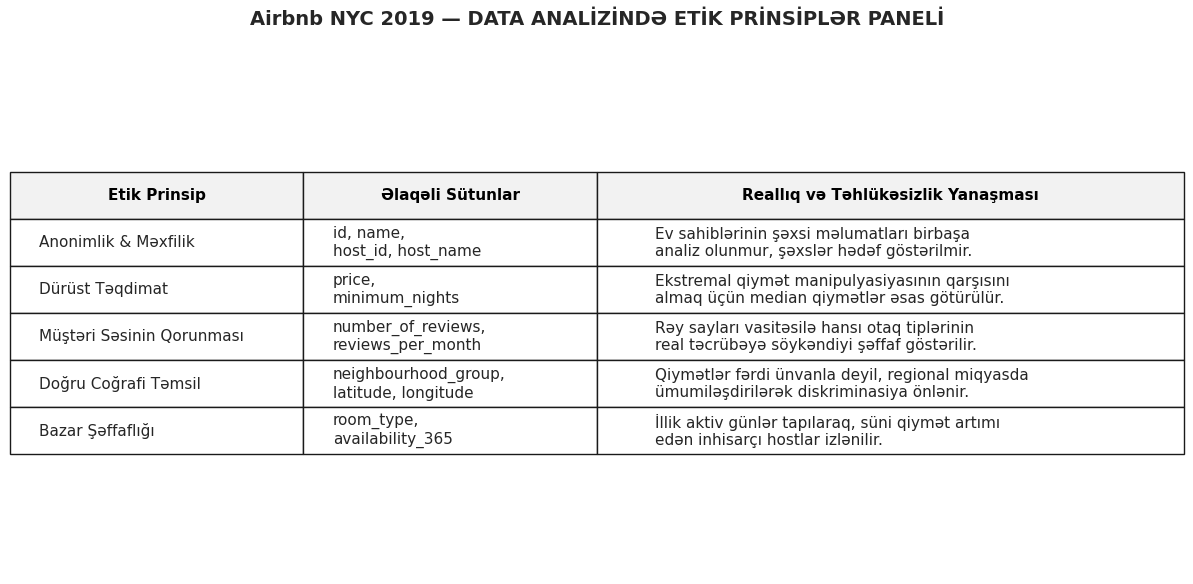

In [21]:
import os
import matplotlib.pyplot as plt
import pandas as pd

fayl_yolu = "təmizlənmiş_data/təmizlənmiş_AB_NYC_2019.csv"

if not os.path.exists(fayl_yolu):
    print(f"XƏTA: '{fayl_yolu}' faylı tapılmadı!")
else:
    # low_memory=False qarışıq tip xəbərdarlığının qarşısını alır
    df = pd.read_csv(fayl_yolu, low_memory=False)

    # Cədvəl daxilində görünəcək məlumatlar
    sütunlar = ["Etik Prinsip", "Əlaqəli Sütunlar", "Reallıq və Təhlükəsizlik Yanaşması"]
    
    məlumatlar = [
        ["Anonimlik & Məxfilik", "id, name,\nhost_id, host_name", "Ev sahiblərinin şəxsi məlumatları birbaşa\nanaliz olunmur, şəxslər hədəf göstərilmir."],
        ["Dürüst Təqdimat", "price,\nminimum_nights", "Ekstremal qiymət manipulyasiyasının qarşısını\nalmaq üçün median qiymətlər əsas götürülür."],
        ["Müştəri Səsinin Qorunması", "number_of_reviews,\nreviews_per_month", "Rəy sayları vasitəsilə hansı otaq tiplərinin\nreal təcrübəyə söykəndiyi şəffaf göstərilir."],
        ["Doğru Coğrafi Təmsil", "neighbourhood_group,\nlatitude, longitude", "Qiymətlər fərdi ünvanla deyil, regional miqyasda\nümumiləşdirilərək diskriminasiya önlənir."],
        ["Bazar Şəffaflığı", "room_type,\navailability_365", "İllik aktiv günlər tapılaraq, süni qiymət artımı\nedən inhisarçı hostlar izlənilir."]
    ]

    # Vizual mətn tablosunun yaradılması
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis("off")  # Qrafik oxlarını, çərçivəni və sayları gizlədirik

    # Mətn cədvəlinin vizual qurulması
    cədvəl = ax.table(
        cellText=məlumatlar, 
        colLabels=sütunlar, 
        loc="center", 
        cellLoc="left",
        colWidths=[0.25, 0.25, 0.5]  # Sütunların genişlik nisbəti
    )

    # Cədvəlin vizual dizaynı (şrift ölçüləri və xətlər)
    cədvəl.auto_set_font_size(False)
    cədvəl.set_fontsize(11)
    cədvəl.scale(1.2, 2.5)  # Hüceyrələrin genişliyi və hündürlüyü (oxunaqlı olması üçün)

    # Başlıq hissəsini bir az fərqləndirmək üçün (qalın şrift)
    for (row, col), cell in cədvəl.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold", color="black")
            cell.set_facecolor("#f2f2f2")  # Başlığın arxa fonu yüngül boz

    plt.title("Airbnb NYC 2019 — DATA ANALİZİNDƏ ETİK PRİNSİPLƏR PANELİ", fontsize=14, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()